<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) Load dataset

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, precision_recall_curve, auc,
    RocCurveDisplay, PrecisionRecallDisplay
)

import matplotlib.pyplot as plt

2) Define columns

In [ ]:
df = pd.read_csv("Crop_training_data_full.csv")  # or "balanced_crop_training_data.csv"

# Target: convert Suitable/Unsuitable -> 1/0
df["target"] = (df["suitability_class"].str.lower() == "suitable").astype(int)

# Features & label
X = df.drop(columns=["suitability_class", "target"])
y = df["target"]

3) Preprocessing

In [ ]:
numeric_features = [
    "temperature", "rainfall", "ph", "organic_carbon",
    "cec", "awc", "bulk_density"
]
categorical_features = ["crop"]  # crop name helps model learn crop-specific patterns


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2 layers (you can change)
    activation="relu",
    solver="adam",
    alpha=1e-4,                    # L2 regularization
    learning_rate_init=1e-3,
    max_iter=300,
    random_state=42
)

# Pipeline = preprocessing + model
model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("mlp", mlp)
])


In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['temperature', 'rainfall',
                                                   'ph', 'organic_carbon',
                                                   'cec', 'awc',
                                                   'bulk_density']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['crop'])])),
                ('mlp',
                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300,
                               random_state=42))])

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # probability of Suitable

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

precision, recall, _ = precision_recall_curve(y_test, y_proba)
auprc = auc(recall, precision)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test ROC-AUC: {roc_auc:.4f}")
print(f"Test AUPRC : {auprc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))


Test Accuracy: 0.8476
Test ROC-AUC: 0.9254
Test AUPRC : 0.9523

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       162
           1       0.89      0.86      0.87       258

    accuracy                           0.85       420
   macro avg       0.84      0.84      0.84       420
weighted avg       0.85      0.85      0.85       420



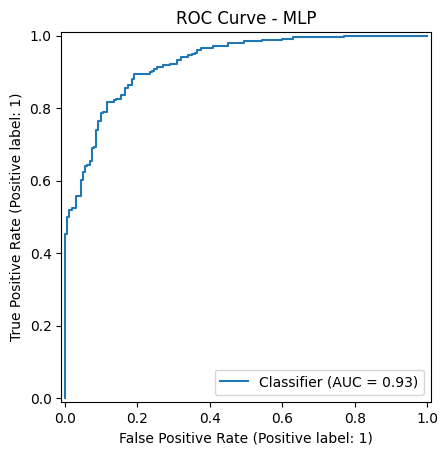

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve - MLP")
plt.show()


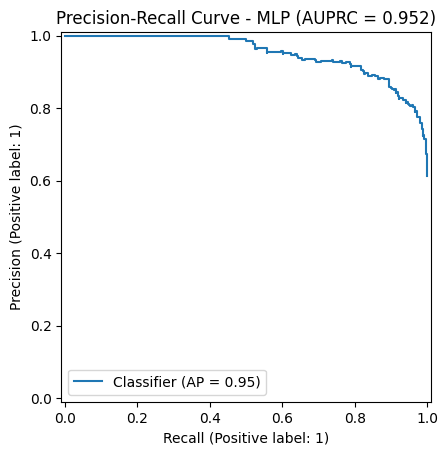

In [ ]:
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title(f"Precision-Recall Curve - MLP (AUPRC = {auprc:.3f})")
plt.show()

Hyperparameter tuning

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, precision_recall_curve, auc
)


In [10]:
df = pd.read_csv("Crop_training_data_full.csv")  # or "balanced_crop_training_data.csv"

# target: Suitable=1, Unsuitable=0
df["target"] = (df["suitability_class"].str.lower() == "suitable").astype(int)

X = df.drop(columns=["suitability_class", "target"])
y = df["target"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [13]:
mlp = MLPClassifier(
    max_iter=400,
    random_state=42,
    early_stopping=True,  # stops if not improving
    n_iter_no_change=15
)

# Redefine preprocessor (as it was not run in the new execution flow)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("mlp", mlp)
])

In [14]:
param_dist = {
    "mlp__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [1e-5, 1e-4, 1e-3, 1e-2],                 # regularization
    "mlp__learning_rate_init": [1e-4, 5e-4, 1e-3, 5e-3],
    "mlp__solver": ["adam"],                                # keep stable
    "mlp__batch_size": [32, 64, 128],
}

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=25,                 # increase to 50 if you want
    scoring="average_precision",  # AUPRC is best for imbalance
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [15]:
search.fit(X_train, y_train)

print("\nBest Params:")
print(search.best_params_)
print(f"Best CV AUPRC: {search.best_score_:.4f}")

best_model = search.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best Params:
{'mlp__solver': 'adam', 'mlp__learning_rate_init': 0.005, 'mlp__hidden_layer_sizes': (128, 64, 32), 'mlp__batch_size': 64, 'mlp__alpha': 0.001, 'mlp__activation': 'tanh'}
Best CV AUPRC: 0.9615


In [16]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

precision, recall, _ = precision_recall_curve(y_test, y_proba)
auprc = auc(recall, precision)

print("\n--- Test Results (Best MLP) ---")
print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"AUPRC    : {auprc:.4f}\n")
print(classification_report(y_test, y_pred))


--- Test Results (Best MLP) ---
Accuracy : 0.8857
ROC-AUC  : 0.9356
AUPRC    : 0.9591

              precision    recall  f1-score   support

           0       0.85      0.86      0.85       162
           1       0.91      0.90      0.91       258

    accuracy                           0.89       420
   macro avg       0.88      0.88      0.88       420
weighted avg       0.89      0.89      0.89       420



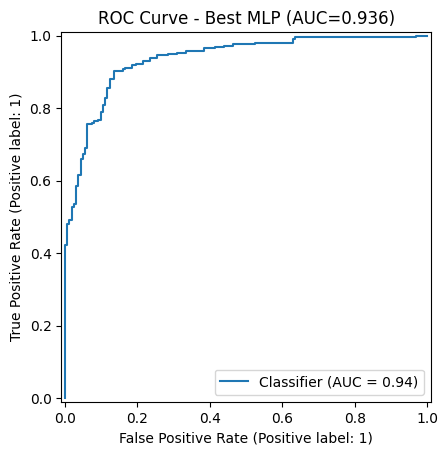

In [17]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f"ROC Curve - Best MLP (AUC={roc_auc:.3f})")
plt.show()


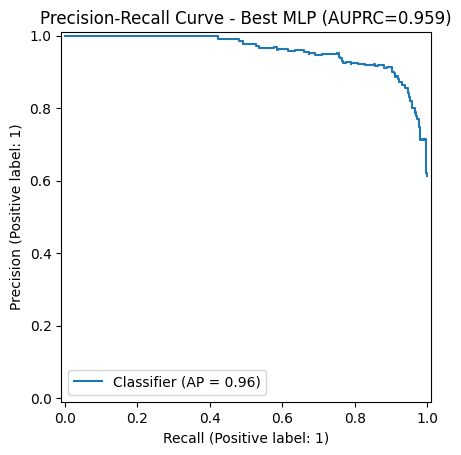

In [18]:
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title(f"Precision-Recall Curve - Best MLP (AUPRC={auprc:.3f})")
plt.show()